In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.arrangements as ar
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations
from Functional_Fusion.util import get_volumes
import SUITPy.flatmap as flatmap
import OptimalBattery.evaluate as ev
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm

In [2]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

# Get group prior (4 parcels trained on mdtb1+mdtb2)

In [3]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [4]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

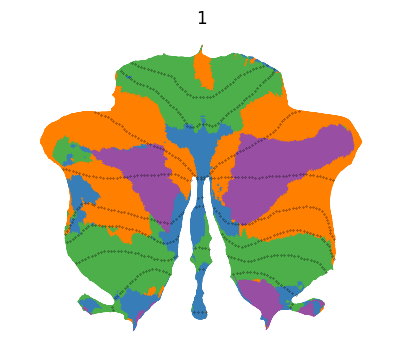

In [5]:
group = full_model.arrange.logpi
group_prob = pt.softmax(group,dim=0)
group_prob = group_prob.reshape(1,-1,group_prob.shape[-1])


group_vol = get_volumes(group_prob.cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(group_vol,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,2),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [6]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

# Load training and testing data

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


# Get Vs and G matrices

In [8]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb_1 = mdtb_1_Vs.detach().numpy()
GL_mdtb_1 = VL_mdtb_1 @ VL_mdtb_1.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

parcel1:Unsure -- parcel2:Motor -- parcel3:socio-linguistic -- parcel4:Multiple demand

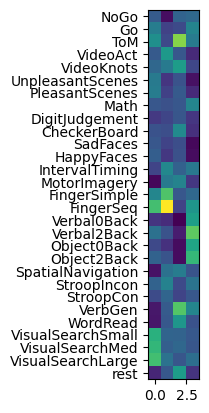

In [9]:
plt.imshow(mdtb_1_Vs)
cond_names = info_mdtb_1_run['cond_name'][:len(VL_mdtb_1)] 
# add condition names from the info file
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

testing motor tasks (fingerseq & fingersimple) in mdtb-s2 in the motor parcel - > make vs and test data

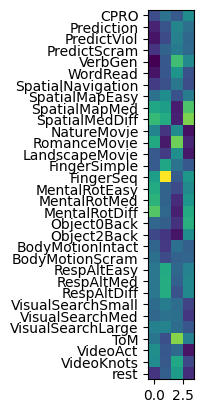

In [10]:
plt.imshow(mdtb_2_Vs)
cond_names = info_mdtb_2_all['cond_name'][:len(VL_mdtb_2)]
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

fingersimple_idx = np.where(info_mdtb_2_all['cond_name'] == 'FingerSeq')[0][0]
fingerseq_idx = np.where(info_mdtb_2_all['cond_name'] == 'FingerSimple')[0][0]
test_task_indices = [fingersimple_idx,fingerseq_idx]

# only motor parcel
vtest = mdtb_2_Vs[test_task_indices,1]
vtest = vtest.reshape(-1,1)
tdata = data_mdtb_s2_all[:,test_task_indices,:]

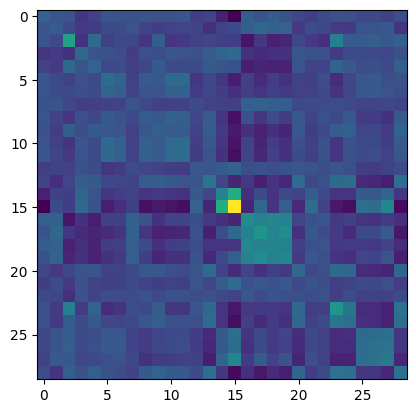

In [11]:
plt.imshow(GL_mdtb_1)

full model for test data, needed for calc_test_error

In [12]:
cond_vec_test = np.tile(np.arange(1, 2 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 2)
data_test = tdata
x_matrix = indicator(cond_vec_test)

em_model = em.MixVMF(K=ar_model.K, P=ar_model.P, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)  

run evaluation on U_hats estimated using HBP framework - data only

In [13]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D_mdtb = ut.build_combinations(GL_mdtb_1, strategy='random',offs = offsets,n_iter=1000,n_tasks=8,seed=4)
D_mdtb , U_list= ev.evaluate_dataframe_real(D_mdtb, data_mdtb_s1_run,VL_mdtb_1,info_mdtb_1_run,tdata, vtest,M_2,ar_model,parcels_to_evaluate=[1],estimation_method='projection')


building0
Processing combination: 0


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:29: RuntimeWarning: invalid value encountered in divide
  X = X / np.linalg.norm(X, axis=axis, keepdims=True)


Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900


- seems like varuance is pretty good at predicting predicition error - both mean subtracted (max_var) and non mean subtracted (max_var_2)
- Potential explanation: with high noise the max_var becomes a better predictor of prediciton error? I tested this in the eval_sim_grid scenario by adding much more noise to the data and looks like it

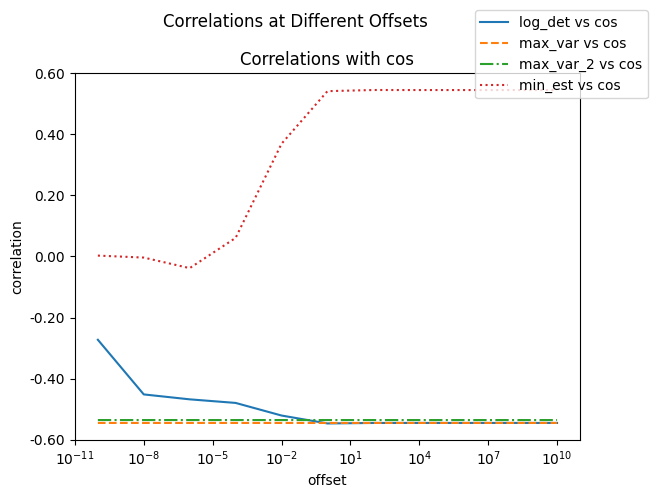

In [14]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','max_var_2','min_est'], y_vars=['cos'])

In [22]:
# find the combination with the lowest cos_HBP , use one offset for the dataframe
D_offset = D_mdtb[D_mdtb['offset'] == 1e-2].reset_index(drop=True)
# find index of lowest mse_ols
# good_battery = D_offset['log_det'].idxmax()
# bad_battery = D_offset['log_det'].idxmin()

good_battery = D_offset['cos'].idxmin()
bad_battery = D_offset['cos'].idxmax()

print(good_battery)
print(bad_battery)


312
266


In [27]:
# find index of FingerSimple and FingerSeq
cond_names = info_mdtb_1_run['cond_name'][:len(VL_mdtb_1)]
fingersimple_idx = np.where(cond_names == 'FingerSimple')[0][0]
fingerseq_idx = np.where(cond_names == 'FingerSeq')[0][0]
traditional_combination = [fingersimple_idx,fingerseq_idx]*4
traditional_combination = tuple(traditional_combination)
print(traditional_combination)
cos_trad,U_hat_trad = ev.evaluate_single_real(traditional_combination, data_mdtb_s1_run,VL_mdtb_1,info_mdtb_1_run,tdata, vtest,M_2,ar_model,parcels_to_evaluate=[1],estimation_method='projection')


(14, 15, 14, 15, 14, 15, 14, 15)


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:29: RuntimeWarning: invalid value encountered in divide
  X = X / np.linalg.norm(X, axis=axis, keepdims=True)


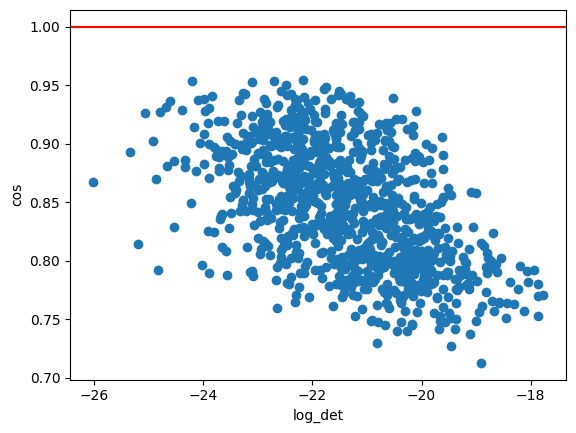

In [18]:
D_specific_offset = D_mdtb[D_mdtb['offset'] == 1e-2]
plt.scatter(D_specific_offset['log_det'], D_specific_offset['cos'])
plt.axhline(y=cos_trad, color='r', linestyle='-')
plt.xlabel('log_det')
plt.ylabel('cos')
plt.show()

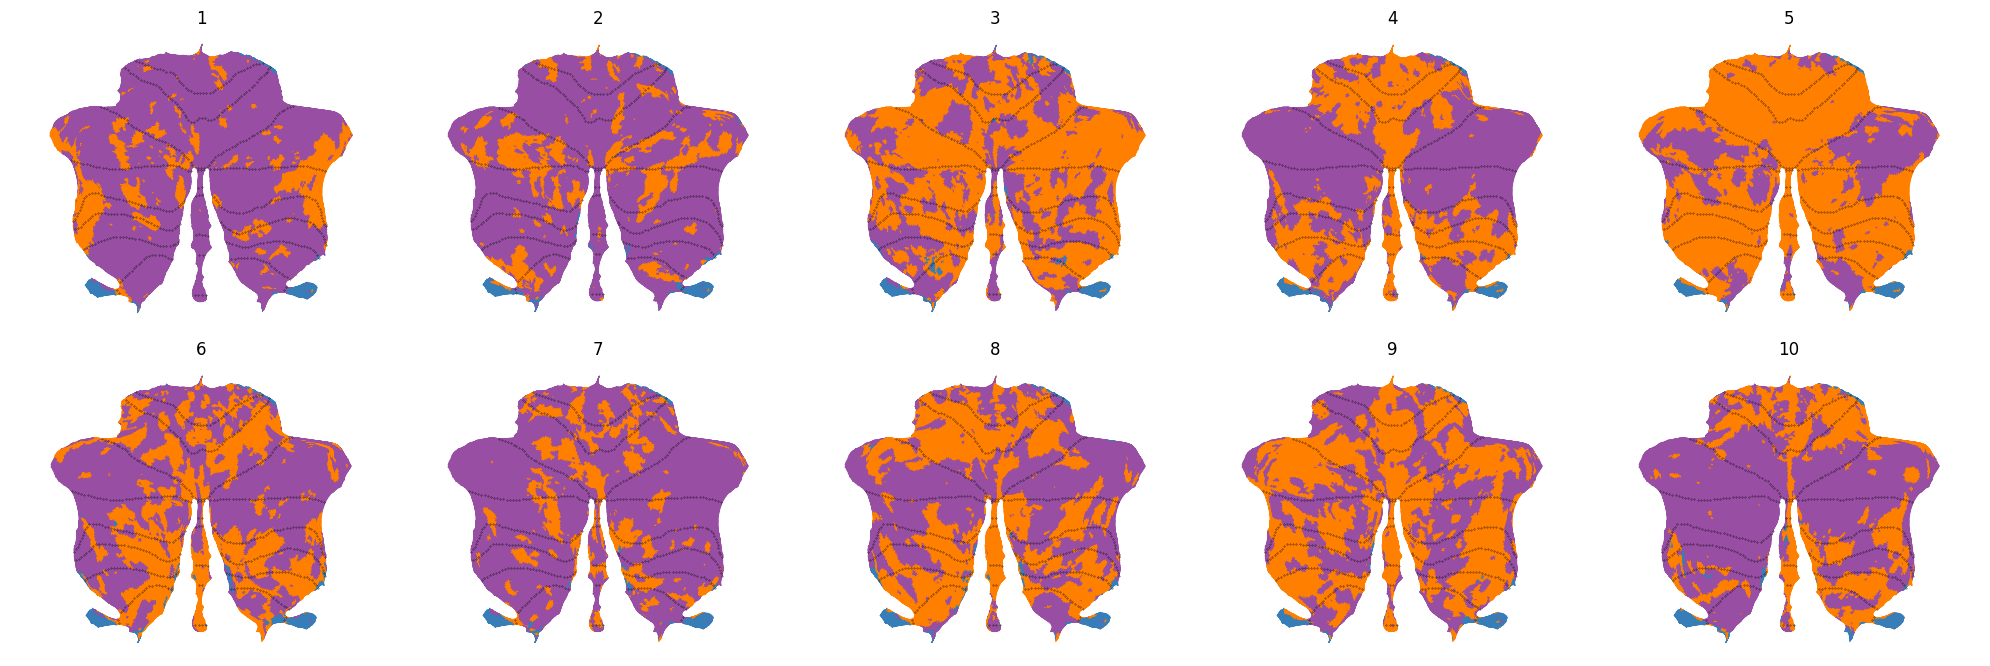

In [19]:
U_individual_volumes = get_volumes(U_hat_trad[:10],atlas_name='SUIT3')
# this function is in SUITPy.flatmap - develop branch. Needs reviewing
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))

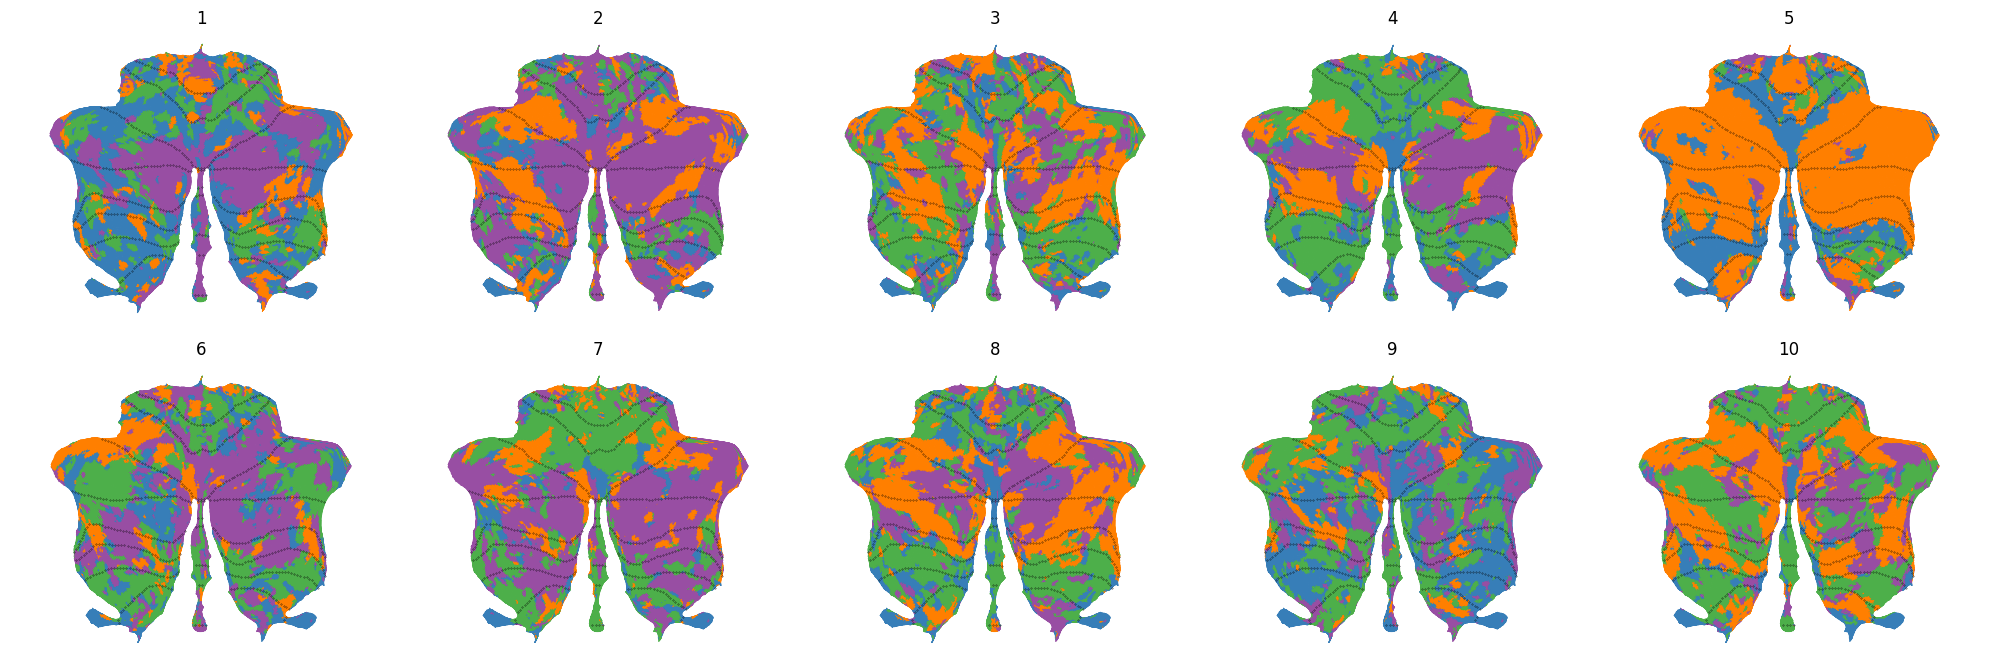

In [20]:
U_individual_volumes = get_volumes(U_list[good_battery][:10],atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))

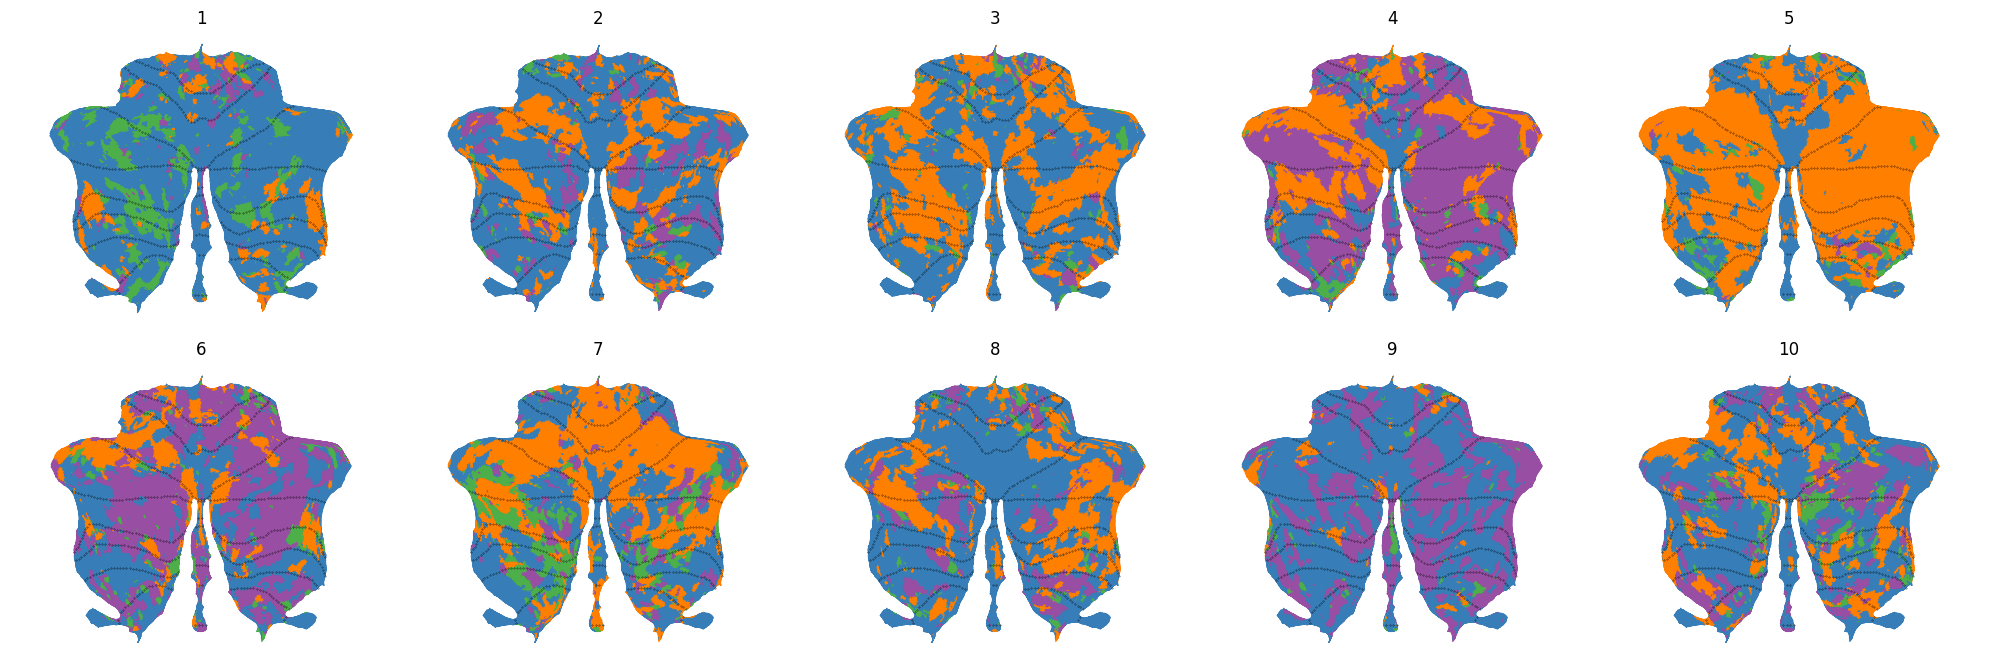

In [23]:
U_individual_volumes = get_volumes(U_list[bad_battery][:10],atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))